In [1]:
import os, json, random, warnings
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from collections import Counter

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog

warnings.filterwarnings('ignore')
SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything()
print("✅ Environment Ready")

✅ Environment Ready


Extracting Crops:   0%|          | 0/8737 [00:00<?, ?it/s]

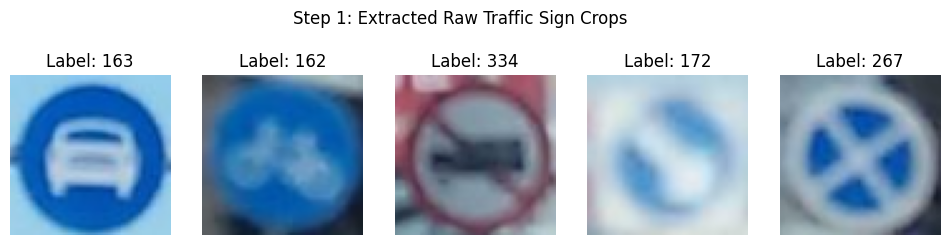

In [2]:
DATA_ROOT = Path('/kaggle/input/datasets/zeuss2k3/mapillary-traffic-sign-dataset')
IMAGE_DIR = DATA_ROOT / 'mtsd_fully_annotated_train_images/images'
ANNOTATION_FILE = DATA_ROOT / 'annotations for mtsd in coco format/annotations for mtsd in coco format/val_coco.json'

with open(ANNOTATION_FILE) as f:
    data = json.load(f)

image_id_to_file = {img['id']: img['file_name'] for img in data['images']}
raw_images, raw_labels = [], []

# We process a subset for efficiency while maintaining variety
for ann in tqdm(data['annotations'][:15000], desc="Extracting Crops"):
    img_name = image_id_to_file.get(ann['image_id'])
    if not img_name: continue
    if not img_name.endswith('.jpg'): img_name += '.jpg'
    
    img_path = IMAGE_DIR / img_name
    if not img_path.exists():
        img_path = DATA_ROOT / 'mtsd_v2_fully_annotated_images.val.zip/images' / img_name
        if not img_path.exists(): continue
    
    img = cv2.imread(str(img_path))
    if img is None: continue
    
    x, y, w, h = map(int, ann['bbox'])
    crop = img[max(0,y):y+h, max(0,x):x+w]
    if crop.size == 0: continue
    
    raw_images.append(cv2.resize(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB), (64, 64)))
    raw_labels.append(ann['category_id'])

# Visualization: Show sample extracted crops
plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(raw_images[i])
    plt.title(f"Label: {raw_labels[i]}")
    plt.axis('off')
plt.suptitle("Step 1: Extracted Raw Traffic Sign Crops")
plt.show()

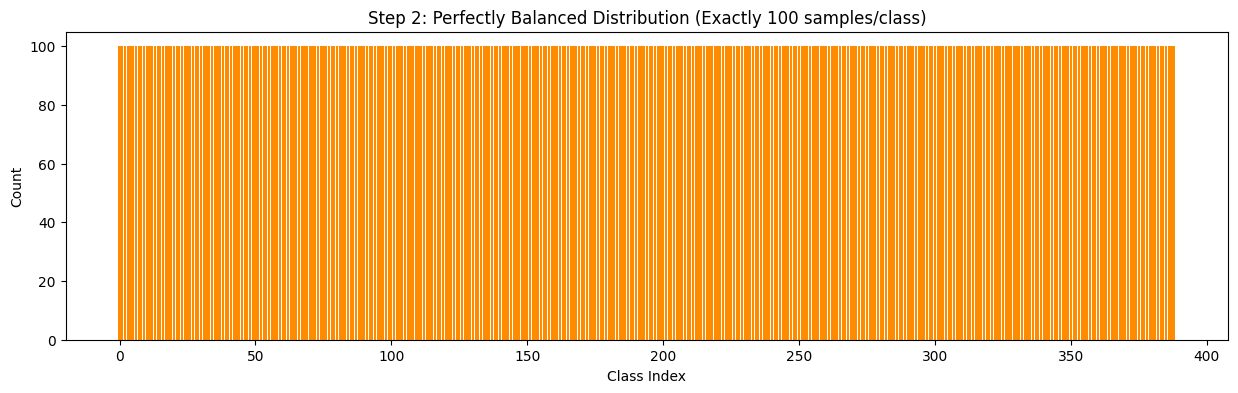

In [3]:
# 1. Remap labels
unique_l = sorted(set(raw_labels))
label_map = {old: new for new, old in enumerate(unique_l)}
y_mapped = np.array([label_map[l] for l in raw_labels])
X_raw = np.array(raw_images)

# 2. Augmentation function to prevent overfitting
def augment_img(img):
    angle = np.random.uniform(-15, 15)
    M = cv2.getRotationMatrix2D((32, 32), angle, 1.0)
    img = cv2.warpAffine(img, M, (64, 64))
    img = cv2.convertScaleAbs(img, alpha=np.random.uniform(0.8, 1.2), beta=10)
    return img

# 3. Balance to exactly 100 samples per class
TARGET = 100
X_bal, y_bal = [], []

for lbl in np.unique(y_mapped):
    idx = np.where(y_mapped == lbl)[0]
    class_imgs = X_raw[idx]
    
    if len(idx) >= TARGET:
        # Downsample majority classes
        X_bal.extend(resample(class_imgs, n_samples=TARGET, replace=False, random_state=SEED))
    else:
        # Augment minority classes
        X_bal.extend(class_imgs)
        for _ in range(TARGET - len(idx)):
            X_bal.append(augment_img(random.choice(class_imgs)))
    y_bal.extend([lbl] * TARGET)

X_bal, y_bal = np.array(X_bal), np.array(y_bal)

# Visualization: Class Distribution Histogram
plt.figure(figsize=(15, 4))
counts = Counter(y_bal)
plt.bar(counts.keys(), counts.values(), color='darkorange')
plt.title(f"Step 2: Perfectly Balanced Distribution (Exactly {TARGET} samples/class)")
plt.xlabel("Class Index")
plt.ylabel("Count")
plt.show()

Extracting HOG Features:   0%|          | 0/38900 [00:00<?, ?it/s]

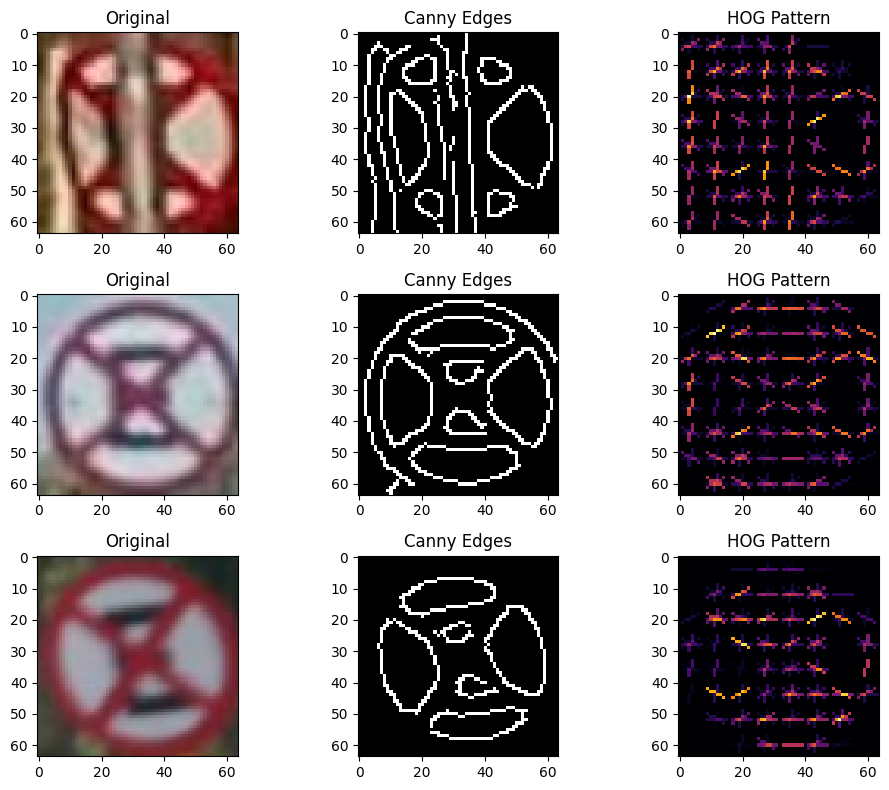

In [4]:
X_feats = []
sample_viz = []

for i, img in enumerate(tqdm(X_bal, desc="Extracting HOG Features")):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    edges = cv2.Canny(blur, 50, 150)
    
    fd, hog_img = hog(edges, orientations=9, pixels_per_cell=(8,8), 
                    cells_per_block=(2,2), block_norm='L2-Hys', visualize=True)
    X_feats.append(fd)
    if i < 3: sample_viz.append((img, edges, hog_img))

X_feats = np.array(X_feats)

# Visualization: The Classical CV Pipeline Comparison
fig, axes = plt.subplots(3, 3, figsize=(10, 8))
for i in range(3):
    axes[i, 0].imshow(sample_viz[i][0]); axes[i, 0].set_title("Original")
    axes[i, 1].imshow(sample_viz[i][1], cmap='gray'); axes[i, 1].set_title("Canny Edges")
    axes[i, 2].imshow(sample_viz[i][2], cmap='inferno'); axes[i, 2].set_title("HOG Pattern")
plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
import time

# 1. Splitting and Scaling
X_train, X_test, y_train, y_test = train_test_split(
    X_feats, y_bal, test_size=0.3, stratify=y_bal, random_state=SEED
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Optimized Tuning Search
# We use a distribution for C to find the best value efficiently
param_distributions = {
    'C': [0.1, 1, 10, 50],
    'kernel': ['linear'] # Linear is mandatory for 389 classes on CPU to avoid crashes
}

# RandomizedSearchCV is more memory-efficient than GridSearchCV
tune_search = RandomizedSearchCV(
    SVC(), 
    param_distributions, 
    n_iter=5,        # It will pick 3 random combinations to test
    cv=5,            # Fewer folds = less memory used
    verbose=3, 
    random_state=SEED,
    n_jobs=-1        
)

print(f"🚀 Starting Lightweight Tuning...")
start_time = time.time()

tune_search.fit(X_train_scaled, y_train)

duration = time.time() - start_time
print(f"\n✅ Tuning finished in {duration:.2f} seconds.")
print(f"🏆 Best Parameters Found: {tune_search.best_params_}")

best_svm = tune_search.best_estimator_

🚀 Starting Lightweight Tuning...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 2/5] END ..............C=0.1, kernel=linear;, score=0.785 total time=13.9min
[CV 2/5] END ................C=1, kernel=linear;, score=0.782 total time=13.7min
[CV 1/5] END ...............C=10, kernel=linear;, score=0.777 total time=13.6min
[CV 3/5] END ...............C=10, kernel=linear;, score=0.792 total time=13.6min
[CV 2/5] END ...............C=50, kernel=linear;, score=0.782 total time=13.6min
[CV 1/5] END ..............C=0.1, kernel=linear;, score=0.779 total time=13.9min
[CV 1/5] END ................C=1, kernel=linear;, score=0.777 total time=13.7min
[CV 4/5] END ................C=1, kernel=linear;, score=0.780 total time=13.7min
[CV 4/5] END ...............C=10, kernel=linear;, score=0.779 total time=13.7min
[CV 3/5] END ...............C=50, kernel=linear;, score=0.792 total time=13.6min
[CV 3/5] END ..............C=0.1, kernel=linear;, score=0.793 total time=13.9min
[CV 5/5] END ...

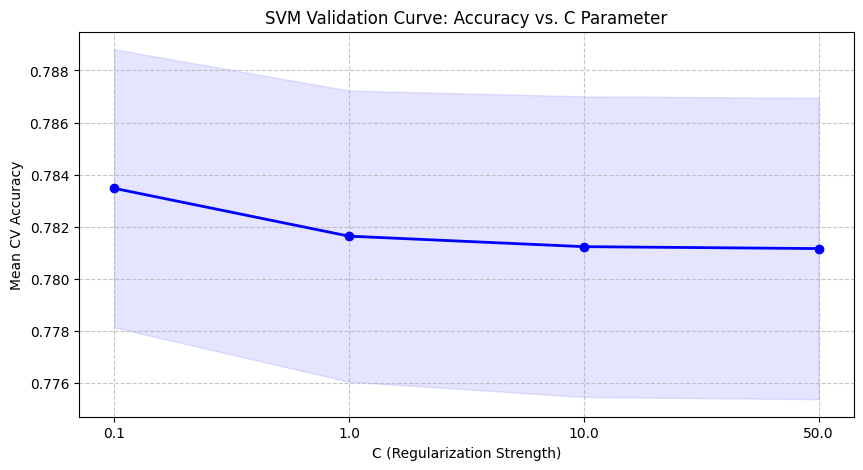

[CV 4/5] END ..............C=0.1, kernel=linear;, score=0.782 total time=14.0min
[CV 3/5] END ................C=1, kernel=linear;, score=0.792 total time=13.7min
[CV 2/5] END ...............C=10, kernel=linear;, score=0.782 total time=13.7min
[CV 1/5] END ...............C=50, kernel=linear;, score=0.777 total time=13.6min
[CV 5/5] END ...............C=50, kernel=linear;, score=0.777 total time=13.7min
🏆 Final Test Accuracy: 0.8028


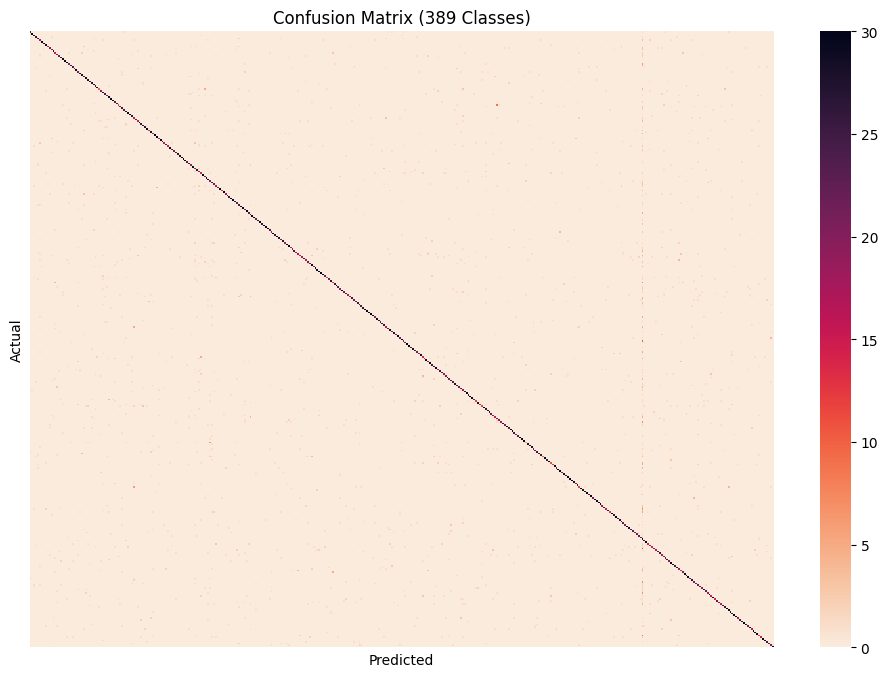

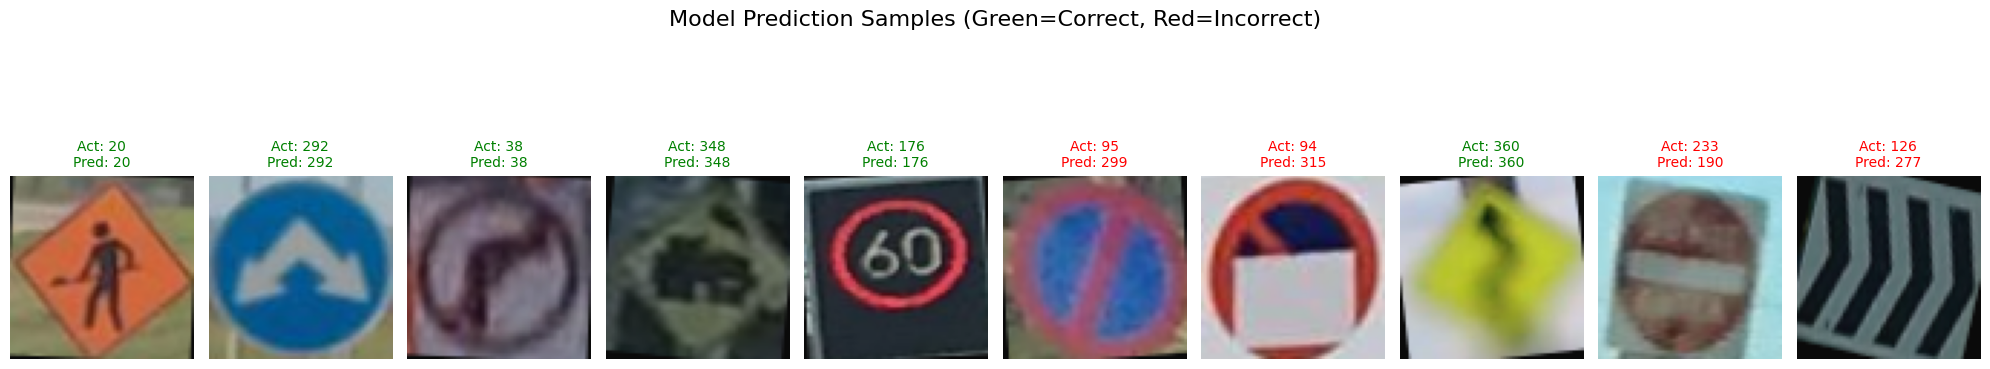

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.metrics import accuracy_score, confusion_matrix

# --- 0. FIXING THE NAME ERROR: Create the image test set ---
# This ensures X_test_imgs matches the indices of y_test perfectly
_, X_test_imgs, _, _ = train_test_split(
    X_bal, y_bal, test_size=0.3, stratify=y_bal, random_state=SEED
)

# --- 5. VISUALIZING TUNING RESULTS (Acc vs. Complexity) ---
results_df = pd.DataFrame(tune_search.cv_results_)
results_df = results_df.sort_values(by='param_C') 

c_values = results_df['param_C'].astype(str)
mean_scores = results_df['mean_test_score']
std_scores = results_df['std_test_score']

plt.figure(figsize=(10, 5))
plt.plot(c_values, mean_scores, marker='o', linestyle='-', color='b', linewidth=2)
plt.fill_between(c_values, 
                 mean_scores - std_scores, 
                 mean_scores + std_scores, 
                 alpha=0.1, color='b')

plt.title("SVM Validation Curve: Accuracy vs. C Parameter")
plt.xlabel("C (Regularization Strength)")
plt.ylabel("Mean CV Accuracy")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- 6. EVALUATION & CONFUSION MATRIX ---
y_pred = best_svm.predict(X_test_scaled)
print(f"🏆 Final Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")

plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, cmap='rocket_r', xticklabels=False, yticklabels=False)
plt.title("Confusion Matrix (389 Classes)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --- 7. PREDICTION GALLERY (10 Samples) ---
num_samples = 10
indices = random.sample(range(len(y_test)), num_samples)

plt.figure(figsize=(20, 4))
for i, idx in enumerate(indices):
    plt.subplot(1, num_samples, i + 1)
    
    # Now X_test_imgs is defined and will work!
    plt.imshow(X_test_imgs[idx])
    
    is_correct = y_test[idx] == y_pred[idx]
    title_color = 'green' if is_correct else 'red'
    
    plt.title(f"Act: {y_test[idx]}\nPred: {y_pred[idx]}", color=title_color, fontsize=10)
    plt.axis('off')

plt.suptitle("Model Prediction Samples (Green=Correct, Red=Incorrect)", fontsize=16, y=1.1)
plt.tight_layout()
plt.show()

In [7]:
from sklearn.metrics import classification_report

# This will print a detailed report for all 389 classes
# Note: It will be a long output!
print("📊 Detailed Classification Report:")
print(classification_report(y_test, y_pred))

📊 Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.80      0.79        30
           1       0.97      1.00      0.98        30
           2       0.82      0.90      0.86        30
           3       0.87      0.87      0.87        30
           4       0.75      0.80      0.77        30
           5       0.50      0.53      0.52        30
           6       0.97      1.00      0.98        30
           7       0.97      1.00      0.98        30
           8       0.83      0.97      0.89        30
           9       0.80      0.53      0.64        30
          10       0.79      0.63      0.70        30
          11       0.70      0.63      0.67        30
          12       0.85      0.93      0.89        30
          13       0.60      0.50      0.55        30
          14       0.69      0.67      0.68        30
          15       0.88      0.73      0.80        30
          16       0.84      0.87      0.85    